In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# if getting OptionError: "No such keys(s): 'mode.use_inf_as_null'"
# !pip install --upgrade seaborn pandas

import matplotlib as mpl
import os
from glob import glob

from _load_data import * # Getting our specific labels, formatting, and data

# Getting some free samples
results_df.sample()

print(gens)

# Don't change any code below, it may break (probably will) --------------------

['../models/SimplifierTopDown1e-1.py', '../models/SimplifierTopDown1e-5.py', '../models/SimplifierTopDownOnlyLast1e-5.py', '../models/SimplifierTopDownOnlyLast1e-1.py', '../models/Vanilla.py', '../models/SimplifierBottomUpOnlyLast1e-3.py', '../models/SimplifierBottomUp1e-3.py', '../models/SimplifierTopDownOnlyLast1e-3.py', '../models/SimplifierBottomUp1e-5.py', '../models/SimplifierBottomUpOnlyLast1e-1.py', '../models/SimplifierTopDown1e-3.py', '../models/SimplifierBottomUp1e-1.py', '../models/SimplifierBottomUpOnlyLast1e-5.py'] ['Top Down 1e-1', 'Top Down 1e-5', 'Top Down 1e-5 (only last)', 'Top Down 1e-1 (only last)', 'Without simplify', 'Bottom Up 1e-3 (only last)', 'Bottom Up 1e-3', 'Top Down 1e-3 (only last)', 'Bottom Up 1e-5', 'Bottom Up 1e-1 (only last)', 'Top Down 1e-3', 'Bottom Up 1e-1', 'Bottom Up 1e-5 (only last)']
(780, 15)
['Top Down 1e-1' 'Top Down 1e-5' 'Top Down 1e-5 (only last)'
 'Top Down 1e-1 (only last)' 'Without simplify'
 'Bottom Up 1e-3 (only last)' 'Bottom Up 1e

In [2]:
dataframes = []
for i, row in results_df.iterrows():
    model, dataset, random_state = row.loc[['model', 'dataset', 'random_state']]

    files = glob(f"{results_path}/{dnames_to_ugly[dataset]}/{nice_to_ugly[model]}/"
                f"*{random_state}_hashes.csv")

    for file in files:
        data = pd.read_csv(file)
        data['model'] = model
        data['dataset'] = dataset
        data['random_state'] = random_state
        dataframes.append(data)
            
dataframes_df = pd.concat(dataframes)
dataframes_df['(only last)'] = dataframes_df['model'].apply(lambda model: model.endswith(r"(only last)"))
dataframes_df['model'] = dataframes_df['model'].apply(lambda model: model.replace(r"(only last)", ""))
dataframes_df[['model', 'threshold']] = dataframes_df['model'].str.split(r' 1e-', expand=True)
dataframes_df['threshold'] = dataframes_df['threshold'].fillna(0).astype(float).apply(lambda power: 10**-power)

dataframes_df = dataframes_df.replace([np.inf, -np.inf], np.nan).dropna()

print(dataframes_df.shape)
print(dataframes_df['model'].unique())
print(dataframes_df['dataset'].unique())
display(dataframes_df.describe())
dataframes_df.sample(5)

(7942283, 12)
['Top Down' 'Without simplify' 'Bottom Up']
['Airfoil' 'Concrete' 'Energy Cooling' 'Energy Heating' 'Housing' 'Yacht']


,key,rmse_train,cos_train,rmse_test,cos_test,random_state,threshold
count,7.942283e+06,7.942283e+06,7.942283e+06,7.942283e+06,7.942283e+06,7.942283e+06,7.942283e+06
mean,4.545820e+03,6.336591e+144,2.313247e-02,2.049905e+144,2.312165e-02,1.404456e+04,3.389666e-02
std,3.783155e+03,1.318090e+148,2.604310e-01,5.271753e+147,2.603563e-01,6.741040e+03,4.763042e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.866000e+03,1.000000e-05
25%,1.408000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.019700e+04,1.000000e-05
50%,3.888000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.335200e+04,1.000000e-03
75%,6.826000e+03,0.000000e+00,1.490116e-08,0.000000e+00,1.490116e-08,1.586000e+04,1.000000e-01
max,2.723500e+04,3.404607e+151,3.141593e+00,1.484090e+151,3.141593e+00,2.975600e+04,1.000000e+00


,key,simplified_to,expression,rmse_train,cos_train,rmse_test,cos_test,model,dataset,random_state,(only last),threshold
2530,1128,"subtract(add(tan(x_10), log1p(x_10)), absolute(sin(x_5)))","subtract(add(tan(x_10), log1p(x_10)), absolute(sin(x_5)))",0.0,1.490116e-08,0.0,0.000000e+00,Top Down,Housing,29756,True,0.00001
7637,6151,"minimum(add(cdiv(-148.3947623412804, x_7), x_1), 28.455582110938643)","minimum(add(cdiv(-148.3947623412804, x_7), x_1), 28.455582110938643)",0.0,0.000000e+00,0.0,0.000000e+00,Top Down,Concrete,13352,False,0.00100
10381,8173,"tan(multiply(arctan(subtract(square(-3.988566847912053), multiply(x_3, expm1(multiply(x_5, 4.268482238329626))))), sin(log(multiply(x_5, 5.589708893180012)))))","tan(multiply(arctan(subtract(square(-3.988566847912053), multiply(x_3, expm1(multiply(x_5, 4.268482238329626))))), sin(log(multiply(x_5, 5.589708893180012)))))",0.0,1.490116e-08,0.0,0.000000e+00,Top Down,Yacht,15860,True,0.10000
5795,3829,"add(510.5258368958324, minimum(x_9, expm1(x_5)))","add(510.5258368958324, minimum(x_9, expm1(x_5)))",0.0,0.000000e+00,0.0,0.000000e+00,Bottom Up,Housing,6654,True,0.00001
7564,5997,"arcsin(add(multiply(x_2, cdiv(0.30716132241768357, x_1)), add(add(add(x_4, -0.18734904842597544), x_4), cdiv(0.03799885601668294, -28.309716822012508))))","arcsin(add(multiply(x_2, cdiv(0.30716132241768357, x_1)), add(add(add(x_4, -0.18734904842597544), x_4), cdiv(0.03799885601668294, -28.309716822012508))))",0.0,2.107342e-08,0.0,1.490116e-08,Top Down,Airfoil,4866,False,0.00100


(3478911, 6)


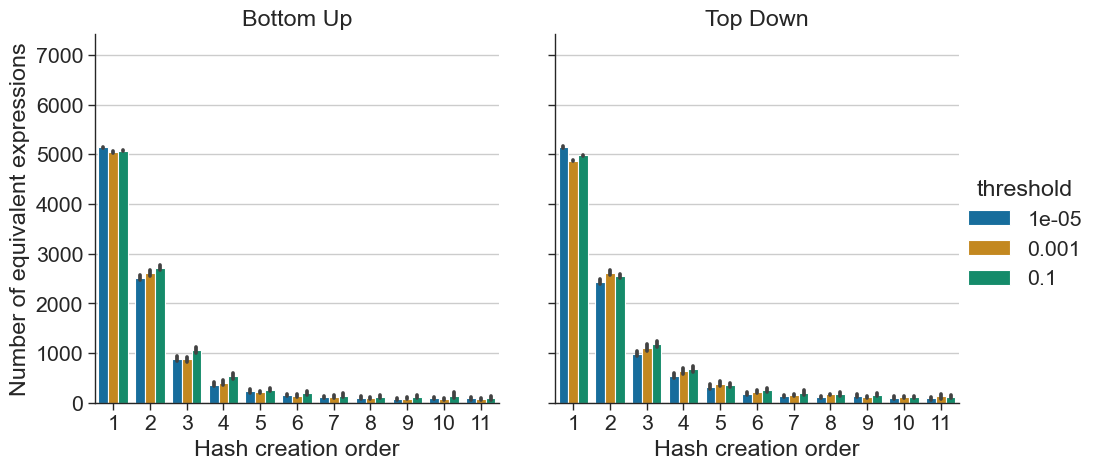

In [5]:
frames = []
for name, group in dataframes_df.groupby(['model', 'threshold', 
                                          '(only last)', 'dataset', 'random_state']):
    model, threshold, only_last, dataset, random_state = name

    if only_last:
        continue
    if model=='Without simplify':
        continue

    data = group['key'].value_counts().reset_index()
    data['dataset'] = dataset
    data['model'] = model
    data['threshold'] = threshold
    data['only_last'] = only_last
    frames.append( data )

frames = pd.concat(frames)
print(frames.shape)

# sns.scatterplot(data=frames, x='key', y='index', hue='dataset')
g = sns.catplot(
    data=frames,
    y='index', x='key', hue="threshold", col='model', # alpha=0.75,
    kind='bar', dodge=True,
    estimator="median",
)

for ax in g.axes.flatten():
    ax.grid(which='major', axis='y', linewidth=1)

g.set_titles("{col_name}").set_axis_labels("Hash creation order", "Number of equivalent expressions")

plt.xlim(-0.5, 10.5)
sns.despine()

plt.savefig(f"../paper/figs/number_of_equivalents.pdf")
plt.savefig(f"../paper/figs/number_of_equivalents.png")
plt.show()

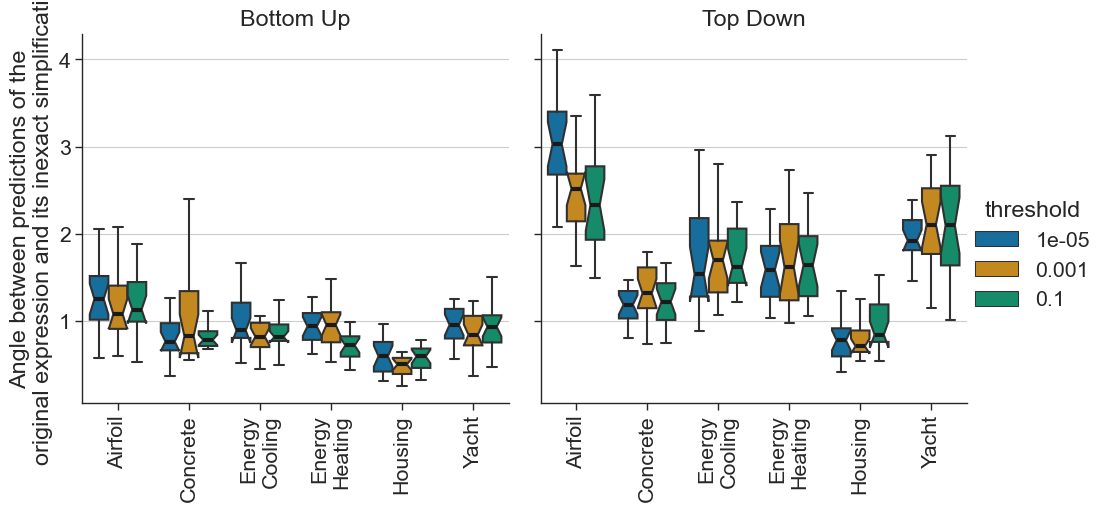

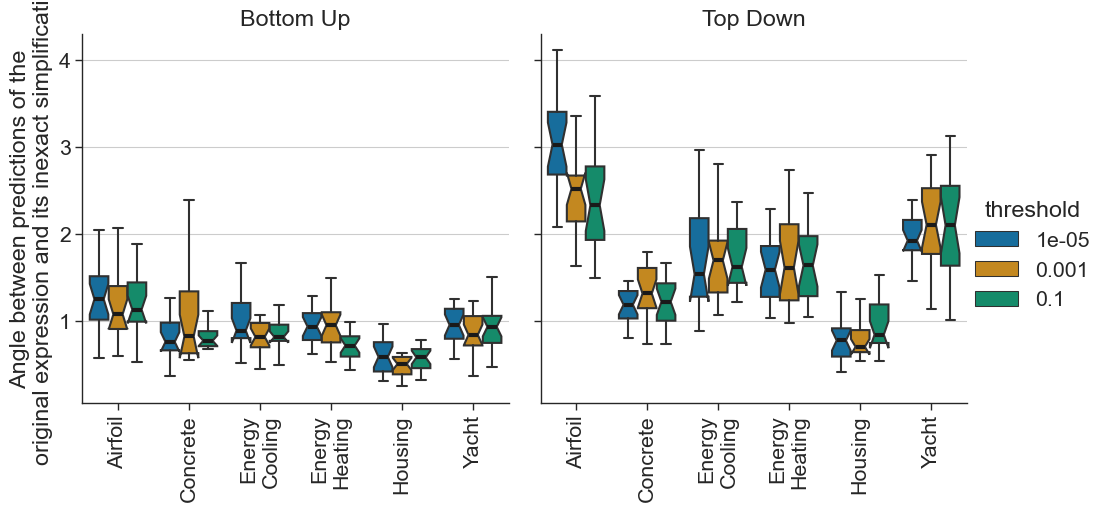

In [6]:
# the first 100 entries seems to have the highest number of equivalent models
frames = []
for name, group in dataframes_df.groupby(['model', 'threshold', 
                                          '(only last)', 'dataset', 'random_state']):
    model, threshold, only_last, dataset, random_state = name

    if model=='Without simplify':
        continue

    frames.append({
        'dataset' : dataset,
        'model' : model,
        'threshold' : threshold,
        'only_last' : only_last,
        'nunique' : group['key'].nunique(),
        'mean_rmse_train' : group['rmse_train'].mean(),
        'mean_rmse_test' : group['rmse_test'].mean(),
        'mean_cos_train' : np.rad2deg(group['cos_train'].mean()),
        'mean_cos_test' : np.rad2deg(group['cos_test'].mean()),
        'total' : group.shape[0]
    })

frames = pd.DataFrame.from_records(frames)

new_kwargs = boxplot_kwargs.copy()
new_kwargs['dodge'] = True

for col in ['mean_cos_train', 'mean_cos_test']:
    g = sns.catplot(
        data=frames,
        y=col, x='dataset', hue="threshold", col='model', # style='(only last)',
        #col_wrap=col_wrap, # markers=marker_choice, # markeredgecolor=None, 
        # order=order, hue_order=order, 
        # estimator="median",
        **new_kwargs, 
    )

    # col_name = "Ângulo entre vetor de\npredições originais e simplificação"
    col_name = "Angle between predictions of the\noriginal expression and its inexact simplification"
    g.set_titles("{col_name}").set_axis_labels("", col_name)
    for (ds, plot_ax) in g._axes_dict.items():
        plot_ax.grid(which='major', axis='y', linewidth=.8)
        plot_ax.set_ylabel(plot_ax.get_ylabel().replace('_', ' '))

        plot_ax.set_xticklabels([t.get_text().replace(" ", "\n") for t in plot_ax.get_xticklabels()])
        for tick in plot_ax.get_xticklabels():
            tick.set(rotation=90, ha='center', va='top', ma='right')
            
        # All vs baseline
        pairs = [('Without simplify', l)
                    for l in data[data['dataset']==ds]['model'].unique()
                    if l != 'Without simplify']

        # pairs = list(combinations(data[data['dataset']==ds]['model'].unique(), 2))

        if False:
            try:
                annotator = Annotator(
                    plot_ax, pairs, data=data[(data['dataset']==ds)],
                    x='model', y=yaxis,
                    order=group_order)
                annotator.reset_configuration()
                annotator.configure(test="Mann-Whitney", # text_format='simple', # hide_non_significant=True, #
                                    comparisons_correction="holm", verbose=0) # , text_offset=-3
                
                # Calculate and annotate
                annotator.apply_and_annotate()
            except Exception as e:
                print(f"failed to add statsannotation with dataset {ds}. Except {e}")

    # sns.scatterplot(data=frames, x='key', y='index', hue='model')
    # sns.despine()
    # plt.yscale("log")
    # plt.xscale("log")
    # plt.xlim(-1, 100)
    # plt.tight_layout()
    plt.savefig(f"../paper/figs/angle_between_original_and_simplified.pdf")
    plt.savefig(f"../paper/figs/angle_between_original_and_simplified.png")

    plt.show()